In [2]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)
print("Numpy:", np.__version__)

TensorFlow: 2.21.0
OpenCV: 5.0.0
Numpy: 2.5.2


In [3]:
import os #Helps Python Work With Folders And File Paths
import cv2
import matplotlib.pyplot as plt

In [4]:
train_path = "../DataSet/Train" # ../ This Use To Go Ine Floder Back
print(train_path)
print(os.path.exists(train_path)) # Finding Location Of Train Folder

../DataSet/Train
True


In [5]:
classes = os.listdir(train_path) #Showing Whatever Info In That Folder

print(classes)
print("Total Classes:", len(classes))

['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']
Total Classes: 43


In [6]:
class_0_path = os.path.join(train_path, "0") #Combining Them Together Safely

print(class_0_path)
print(os.path.exists(class_0_path))

../DataSet/Train\0
True


In [7]:
class_0_images = os.listdir(class_0_path) #Going Inside The 0th Folder 

print(class_0_images[:10]) #Peeking The First 10 Files
print("Total Images In Class 0:", len(class_0_images)) #Counting The Total Data

['00000_00000_00000.png', '00000_00000_00001.png', '00000_00000_00002.png', '00000_00000_00003.png', '00000_00000_00004.png', '00000_00000_00005.png', '00000_00000_00006.png', '00000_00000_00007.png', '00000_00000_00008.png', '00000_00000_00009.png']
Total Images In Class 0: 210


In [8]:
image_name = class_0_images[0] #Select 1st Img
image_path = os.path.join(class_0_path, image_name) # Creating Path To Img
image = cv2.imread(image_path) #Read Img Using Opencv

print("Image Name:", image_name)
print("Image Shape:", image.shape) #Given Heg,Wid,Shp Etc.

Image Name: 00000_00000_00000.png
Image Shape: (30, 29, 3)


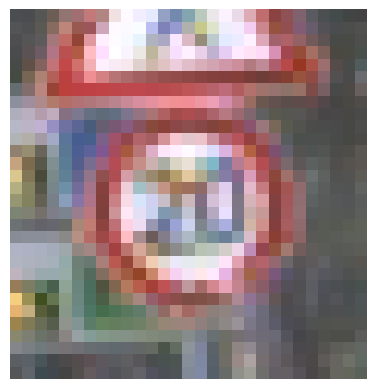

In [9]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # OpenCV reads images in BGR format, while Matplotlib expects RGB.
plt.axis("Off")
plt.show()

In [10]:
#Resizing The Image Into 32*32 Pixels

resized_image = cv2.resize(image,(32,32))

print("Original Shape:", image.shape)
print("Resized Shape:", resized_image.shape)

Original Shape: (30, 29, 3)
Resized Shape: (32, 32, 3)


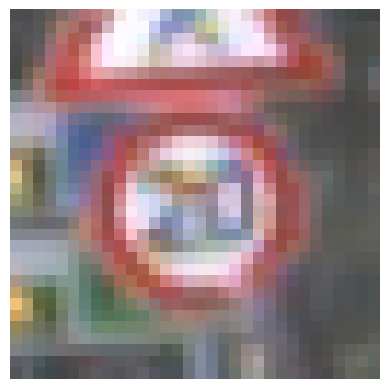

In [11]:
#Comparing Before And After Resizing

plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
plt.axis("Off")
plt.show()

In [12]:
#Normalization The Image

normalized_image = resized_image / 255.0    # Divide each pixel value by 255 to convert the range from 0–255 to 0–1

print("Minimum Pixel Value:", normalized_image.min())
print("Maximun Pixel Value:", normalized_image.max())

Minimum Pixel Value: 0.20784313725490197
Maximun Pixel Value: 1.0


In [13]:
# Count The Number of img present in every Traffic Sign Class

class_image_counts = {}  #Empty Dictionary to Store IMG Count

for class_name in classes:   #Go Through Every Traffic Sign Class
    class_path = os.path.join(train_path, class_name)   #Create The Path To The Current Class Folder
    class_image_counts[class_name] = len(os.listdir(class_path))  #Count the img inside current class

print(class_image_counts)

{'0': 210, '1': 2220, '10': 2010, '11': 1320, '12': 2100, '13': 2160, '14': 780, '15': 630, '16': 420, '17': 1110, '18': 1200, '19': 210, '2': 2250, '20': 360, '21': 330, '22': 390, '23': 510, '24': 270, '25': 1500, '26': 600, '27': 240, '28': 540, '29': 270, '3': 1410, '30': 450, '31': 780, '32': 240, '33': 689, '34': 420, '35': 1200, '36': 390, '37': 210, '38': 2070, '39': 300, '4': 1980, '40': 360, '41': 240, '42': 240, '5': 1860, '6': 420, '7': 1440, '8': 1410, '9': 1470}


In [14]:
# Add all class image counts to get the total number of training images

total_images = sum(class_image_counts.values())

print("Total Training Images:", total_images)

Total Training Images: 39209


In [15]:
# Reading 1st Img from class 0

first_image_path = os.path.join(class_0_path, class_0_images[0]) 

first_image = cv2.imread(first_image_path)  # Read IMG Use OpenCV

print("Data Type:", first_image.dtype)  # Cheking type of data stored in img
print("Image Shape:", first_image.shape)  # CHECK H-W-C 

Data Type: uint8
Image Shape: (30, 29, 3)


In [16]:
# Create empty lists to store images and labels

X = []
y = []

print("X and y are ready")

X and y are ready


In [17]:
# Loop through all traffic sign classes
for class_name in classes:
    class_path = os.path.join(train_path, class_name)  # Get class folder

    # Loop through every image in the class
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)  # Get image path

        image = cv2.imread(image_path)  # Read image
        image = cv2.resize(image, (32, 32))  # Resize image
        image = image / 255.0  # Normalize pixels

        X.append(image)  # Store image
        y.append(int(class_name))  # Store class label

print("Total Images Loaded:", len(X))  # Count images
print("Total Labels Loaded:", len(y))  # Count labels

Total Images Loaded: 39209
Total Labels Loaded: 39209


In [18]:
# Converintg IMG And Lab To NP Array

# Convert image list into NumPy array
X = np.array(X)   # Convert images to NumPy format

# Convert label list into NumPy array
y = np.array(y)  # Convert labels to NumPy format

# Check the shapes of both arrays
print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (39209, 32, 32, 3)
Y Shape: (39209,)


In [19]:
# Checking data type of IMG And Label Array

print("X Data Type:", X.dtype)  # Check IMG DT
print("Y Data Type:", y.dtype)  # Checl Label DT

X Data Type: float64
Y Data Type: int64


In [20]:
# Checking x and y separately

# Cheking Pixel Range Of IMG Data

print("X Minimum:", X.min()) 
print("X Maximum:", X.max())

# Cheking Range Of Class Labels

print("y Minimum:", y.min())
print("y Maximum:", y.max())   

X Minimum: 0.0
X Maximum: 1.0
y Minimum: 0
y Maximum: 42


In [21]:
# Import The FUnction Used Split Datset

from sklearn.model_selection import train_test_split

print("Train/Test Split Library: Ready")

Train/Test Split Library: Ready


In [22]:
# Now W will take 80% IMG For Training An 20% IMG For Validitation

#Split IMG And Lab Into Training Andn Validation Data

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y)

#Check The Size Of Each Dataset

print("X_Train Shape:", X_train.shape)
print("X_val Shape:", X_val.shape)
print("y_train Shape:", y_train.shape)
print("y_val Shape:", y_val.shape)

X_Train Shape: (31367, 32, 32, 3)
X_val Shape: (7842, 32, 32, 3)
y_train Shape: (31367,)
y_val Shape: (7842,)


In [23]:
# Verifying Training And Validation Labels

#Find The Unique Classes Training Labels
train_classes = np.unique(y_train)

#Find the unique classes validation labels
val_classes = np.unique(y_val)

#Display the classes in each set
print("Training Classes:", train_classes)
print("Validation Classes:", val_classes)

#Display the number of classes
print("Training Class Count:", len(train_classes))
print("Validation Class Count:", len(val_classes))

Training Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]
Validation Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]
Training Class Count: 43
Validation Class Count: 43


In [24]:
#Saving The Processed Data

# Save The training images as a NumPy file
np.save("../Model/X_train.npy", X_train)

# Save the validation images as a NumPy file
np.save("../Model/X_val.npy", X_val)

# Save the training labels as a NumPy file
np.save("../Model/y_train.npy", y_train)

# Save the validation labels as a NumPy file
np.save("../Model/y_val.npy",y_val)

# Confirm that all processed files were saved
print("Processed dataset saved successfully!")

Processed dataset saved successfully!
